# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries and data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# this will help in making the Python code more structured automatically (good coding practice)


import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

In [ ]:
# Importing dataset:
visa = pd.read_csv('/content/drive/MyDrive/DSBA program/5. Ensemble Techniques/EasyVisa.csv')

In [ ]:
# copying data to another variable to avoid any changes to original data
data = visa.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# Check size of data set:
data.shape

(25480, 12)

In [ ]:
# Check data types of data set:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


Observation:  Looks like there are no missing values. Two columns are integers, one column is a float datatype, the rest are all string data types.

In [ ]:
# Check for duplicate values:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [ ]:
# Check the first five rows of data set:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [ ]:
# Let's check the statistical summary of the data:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


We observe a negative number in the ['no_of_employees'] column.  

In [ ]:
# Fix the negative values in no_of_employees column:
data[data['no_of_employees']<0]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [ ]:
# Let's create a separate df for the negative values in the no_of_employees column:
negative_no_of_employees = data[data['no_of_employees']<0]
negative_no_of_employees.shape

(33, 12)

In [ ]:
# Convert the negative values in the data into positive numbers:
data['no_of_employees'] = data['no_of_employees'].abs()

In [ ]:
filter = data['no_of_employees']<0
filter.sum()

np.int64(0)


###Let's check the count of each unique category in each of the categorical variables.

In [ ]:
# First, make a list of all categorical variables:
cat_cols = list(data.select_dtypes("object").columns)

# Second, print number of count of each unique value in each column:
for column in cat_cols:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [ ]:
# Check unique values in numeric column['case_id']:
data['case_id'].nunique()

25480

In [ ]:
# The ['case_id'] columnn does not contribute information to the dataset.  Let's drop it:
data.drop(['case_id'], axis=1, inplace= True)  ## axis=1 argument: specifies we want to drop a column; inplace=True: we directly edit the original database, which is now modified.

## Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

###Observation on number of employees:

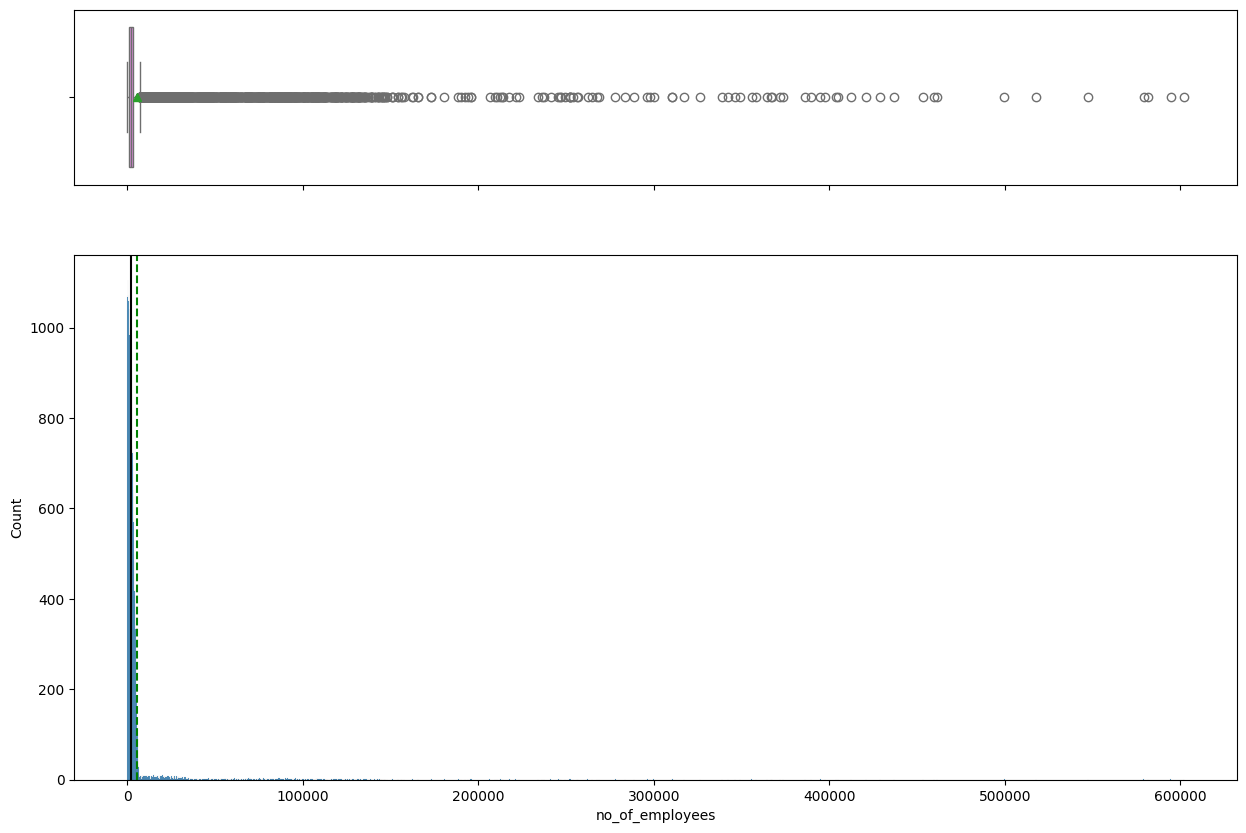

In [ ]:
histogram_boxplot(data, 'no_of_employees')

We observe a very long right tailed distribution in the column no_of_employees, which indicates that more than 75% of companies seeking to hire foreign employees, are businesses with less than 1000 employees.

#### Observations on prevailing wage:

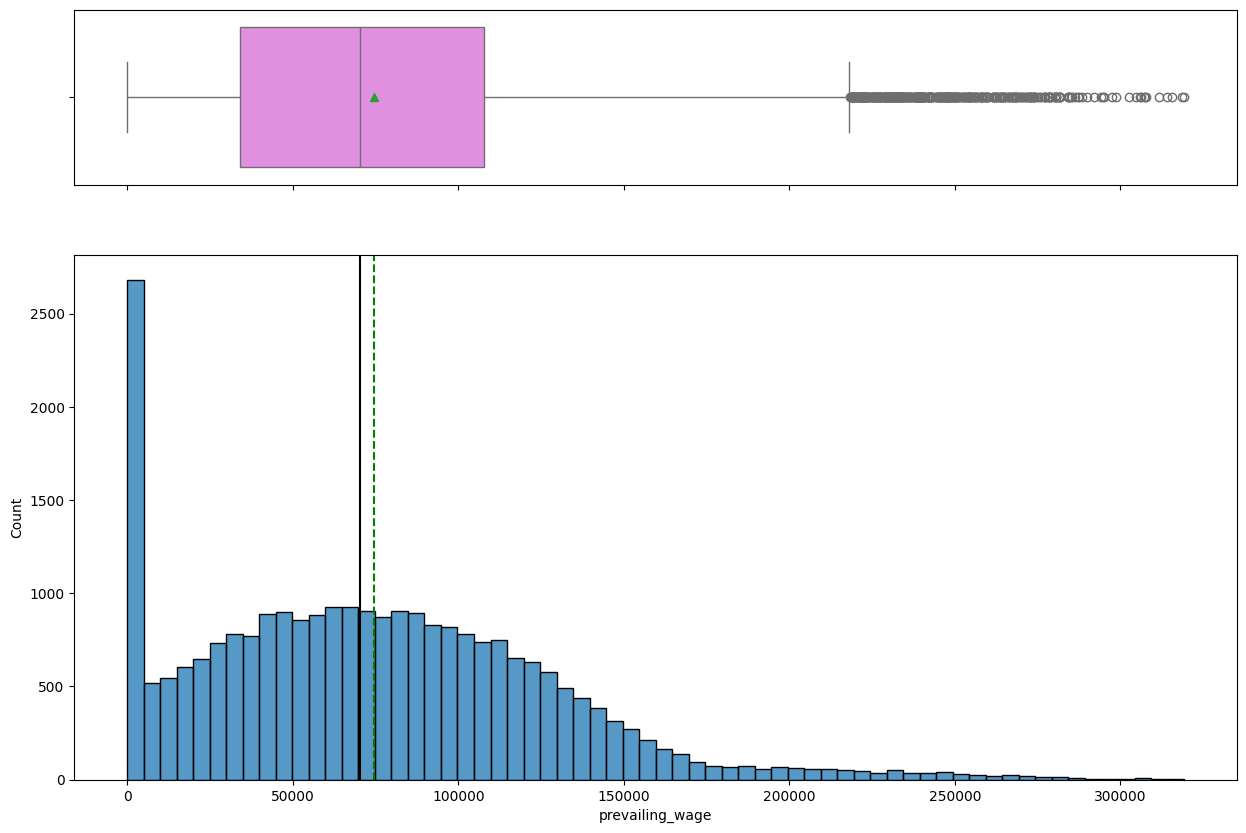

In [ ]:
histogram_boxplot(data, 'prevailing_wage')

We observe that the mean for prevailing wage is around 75,000 USD, with a long right skewed tail up to more than 300,000 USD.  On the other end of the distribution, we see a peak of more than 2500 cases that start with minimal wages of 0-5000 USD.

In [ ]:
# Check if there are prevailing wages lower than 100 USD:
data[data['prevailing_wage']<100]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
338,Asia,Bachelor's,Y,N,2114,2012,Northeast,15.7716,Hour,Y,Certified
634,Asia,Master's,N,N,834,1977,Northeast,3.3188,Hour,Y,Denied
839,Asia,High School,Y,N,4537,1999,West,61.1329,Hour,Y,Denied
876,South America,Bachelor's,Y,N,731,2004,Northeast,82.0029,Hour,Y,Denied
995,Asia,Master's,N,N,302,2000,South,47.4872,Hour,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...
25023,Asia,Bachelor's,N,Y,3200,1994,South,94.1546,Hour,Y,Denied
25258,Asia,Bachelor's,Y,N,3659,1997,South,79.1099,Hour,Y,Denied
25308,North America,Master's,N,N,82953,1977,Northeast,42.7705,Hour,Y,Denied
25329,Africa,Bachelor's,N,N,2172,1993,Northeast,32.9286,Hour,Y,Denied


We observe there are 176 out of 25,480 cases where the prevailing wage is less than 100 USD, and they are most likely all hourly wages.

In [ ]:
# Confirm the assumption that data['prevailing wages']< 100 all have hour as ['unit_of_wage'] (as opposed to week / month / year units):
data.loc[data["prevailing_wage"]<100]["unit_of_wage"].describe()

,unit_of_wage
count,176
unique,1
top,Hour
freq,176


In [ ]:
# Another way of confirming the assumption, using the groupby function:
data.groupby(data['prevailing_wage']<100)['unit_of_wage'].describe()

,count,unique,top,freq
prevailing_wage,,,,
False,25304,4,Year,22962
True,176,1,Hour,176


In [ ]:
# Get the count of values in the ['unit_of_wage'] column when ['prevailing_wage'] <100:
data.loc[data["prevailing_wage"] < 100, "unit_of_wage"].nunique()

1

We observe that the large peak around 0 < 100 usd in the histogram boxplot can be attributed to hourly paid employees.

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on continent:

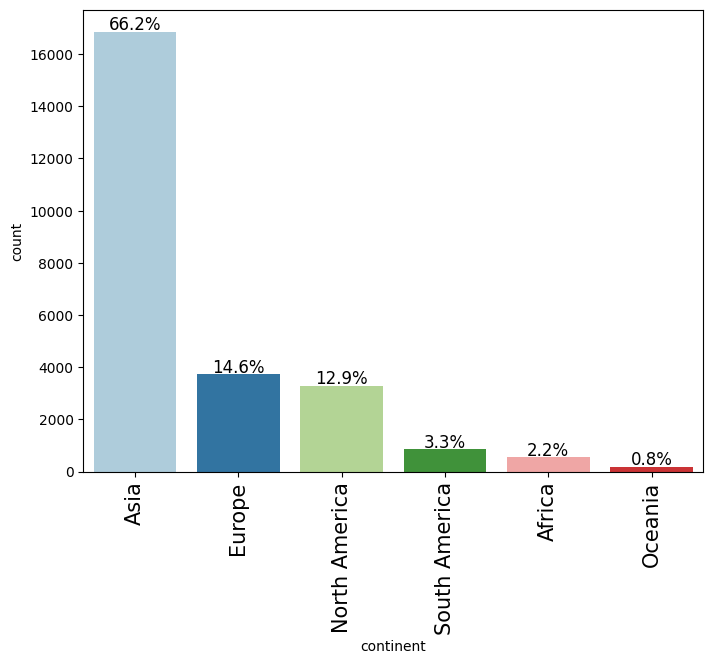

In [ ]:
# Create a barplot to make observations on distribution of the continent column:
labeled_barplot(data, 'continent', perc=True)

We observe the overwhelming majority of visa applicants are originating from Asian countries.

#### Observations on education of employee:

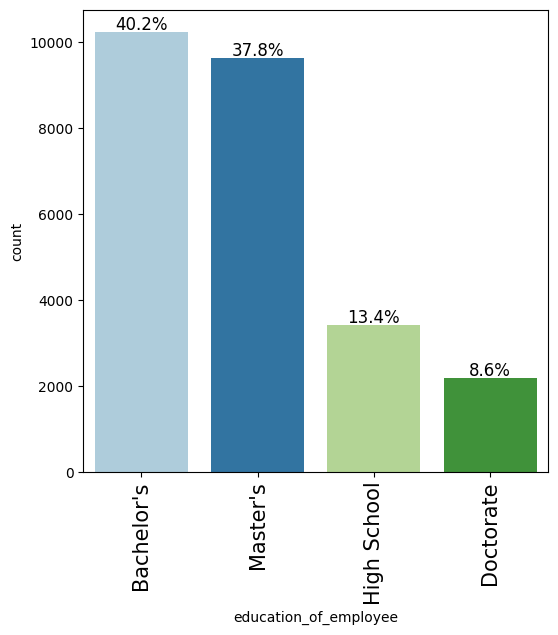

In [ ]:
# Create a barplot of the education of employee column:
labeled_barplot(data, 'education_of_employee', perc=True)

We observe that a Bachelor's and Master's are the two most prevalent degrees among visa applicants.

#### Observations on job experience:

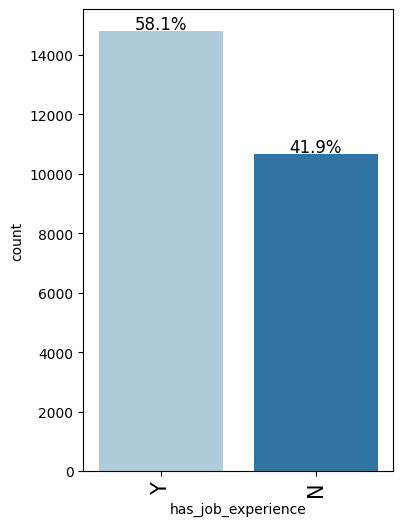

In [ ]:
# Create a barplot on the column job experience:
labeled_barplot(data, 'has_job_experience', perc=True)

We observe that the majority of applicants has prior job experience.

####Observations on job training:

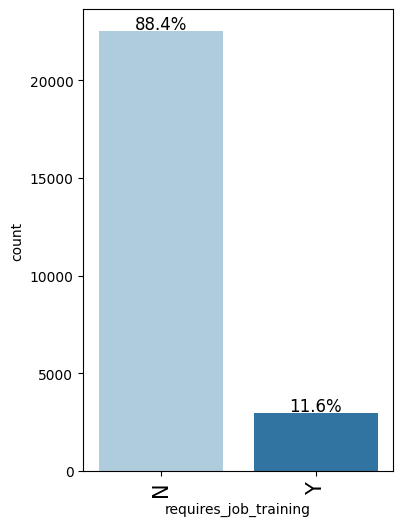

In [ ]:
# Create a barplot on job training:
labeled_barplot(data, 'requires_job_training', perc=True)

We observe that a large majority of the applicants does not require any job training.

####Observations on regions of employment:

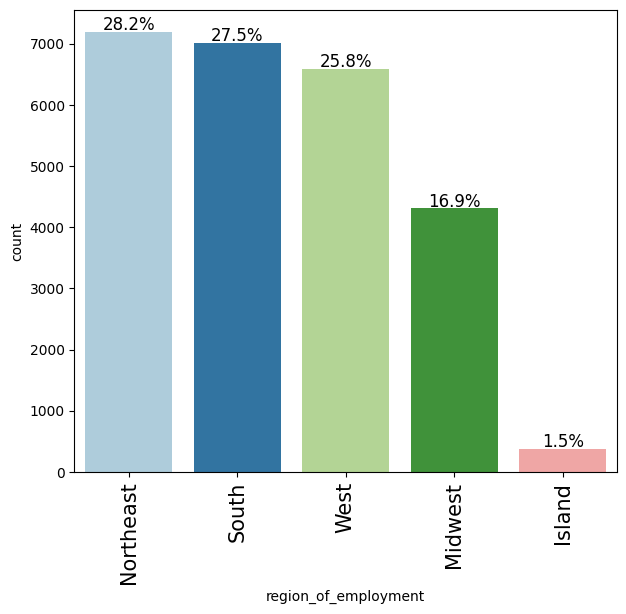

In [ ]:
# Create a barplot on regions of employment:
labeled_barplot(data, 'region_of_employment', perc=True)

We observe that the majority of applicants finds employment in the Northeast, South and West of USA.

####Observation on unit of wage:

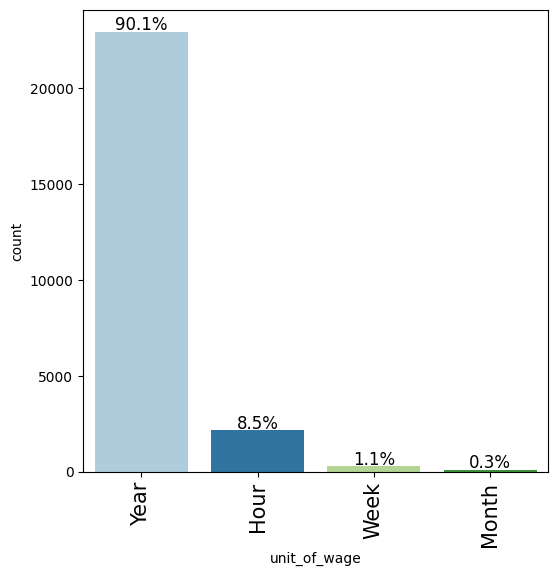

In [ ]:
#Create a barplot on unit_of_wage:
labeled_barplot(data,'unit_of_wage', perc=True)

We observe that more than 90% of applicants reports their wages on annual basis.

####Observation on case status:

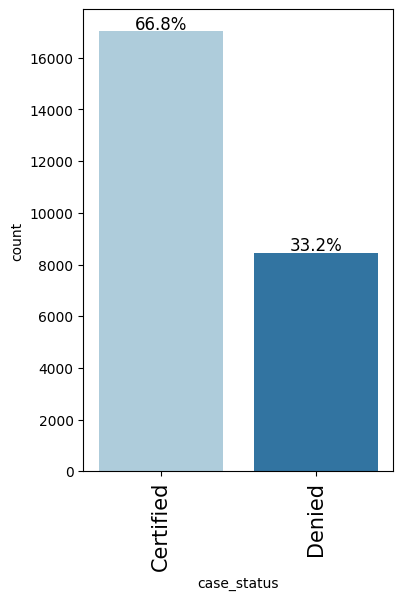

In [ ]:
# Create a barplot on case status:
labeled_barplot(data, 'case_status', perc=True)

We observe that 66.8% of the applicants receives a visa, while 33.2% is denied.

###Bivariate Analysis

In [ ]:
# Let's find correlations between the numerical variables by creating a correlation matrix:
# Let's group the numerical variables first:
num_cols = list(data.select_dtypes("number").columns)
num_cols


['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [ ]:
# Create a correlation matrix to find out correlation between numerical columns:
corr_matrix = data[num_cols].corr()
corr_matrix

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


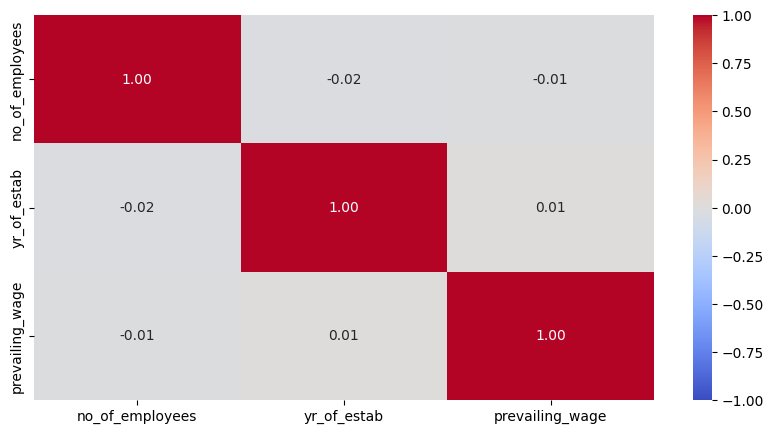

In [ ]:
# Let's visualize with a correlation heatmap:
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap= 'coolwarm')
plt.show()

We observe little to no correlation among the numerical variables.

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


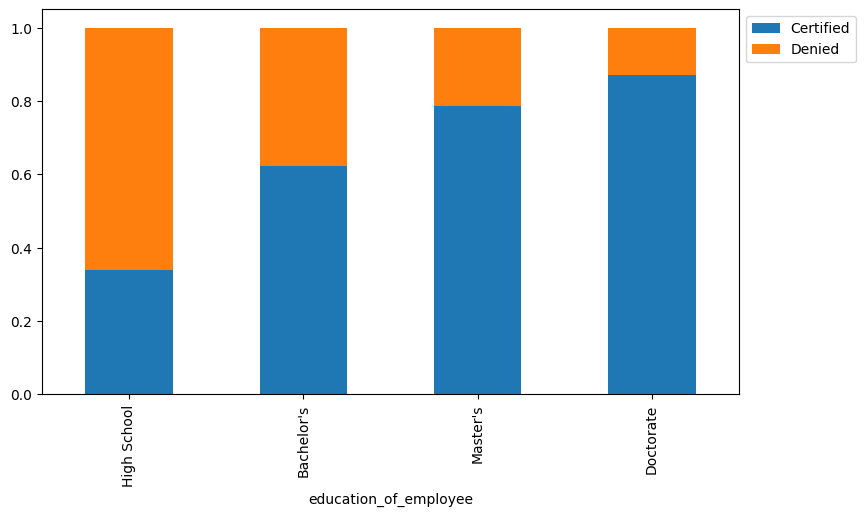

In [ ]:
# Does education play a role in visa certification?
stacked_barplot(data, 'education_of_employee', 'case_status')

We observe that applicants with only a high school diploma are rejected at least twice as likely as ones with a bachelor's degree and higher.

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


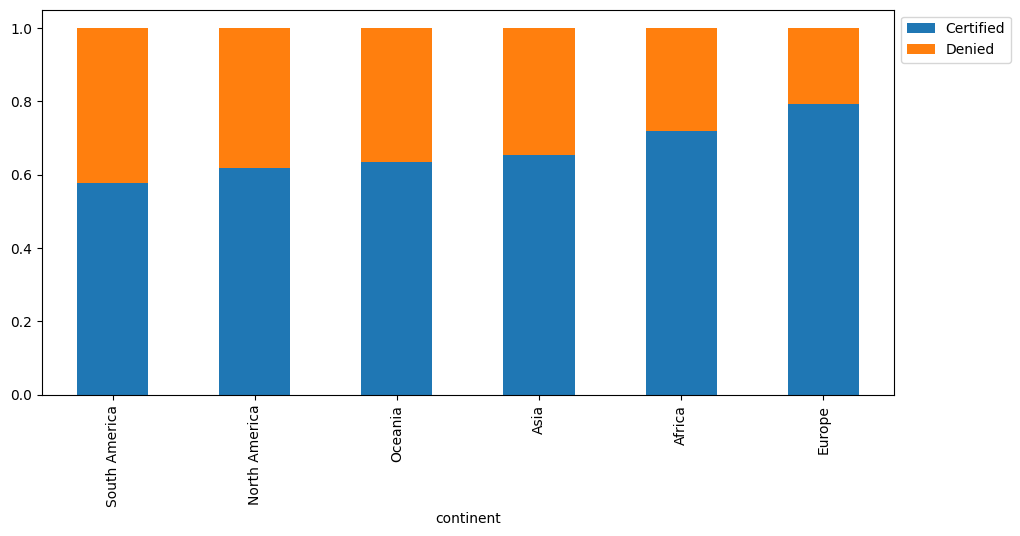

In [ ]:
# How does the visa status varies across continents?
stacked_barplot(data, 'continent', 'case_status')

We observe that applicants from South and North America have higher percentages of visa denial, and applicants from Europe the least.

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


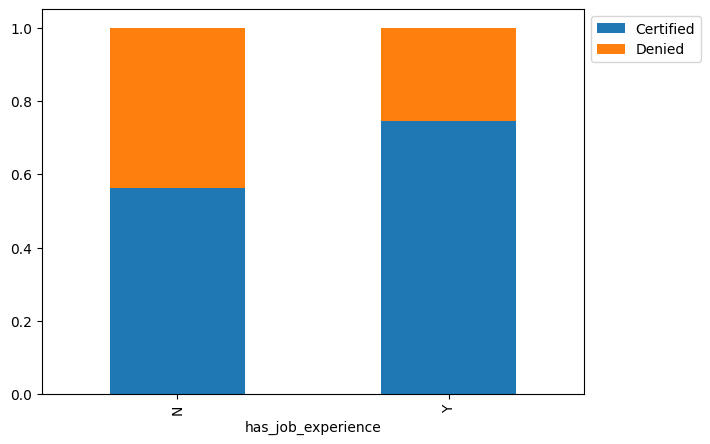

In [ ]:
# Does work experience influence visa status?
stacked_barplot(data, 'has_job_experience', 'case_status')

We observe that applicants with no prior job experience have about double the chance of being denied a visa.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


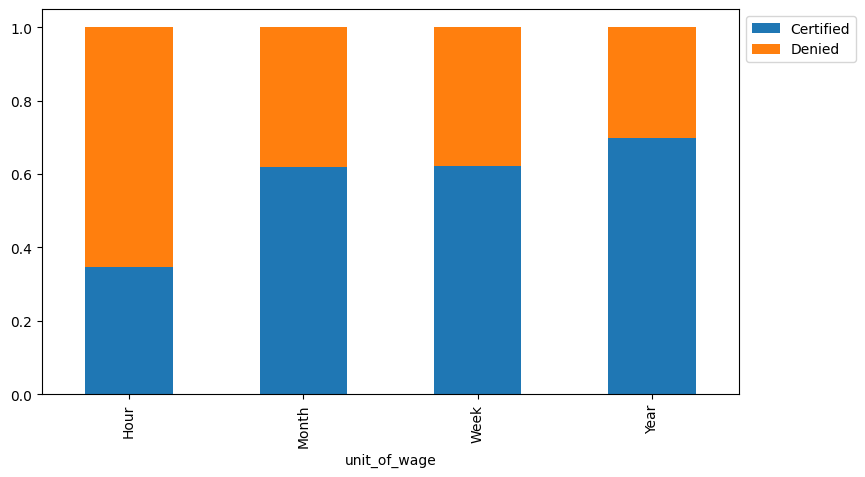

In [ ]:
# Which pay unit is most likely for an applicant to receive visa approval:
stacked_barplot(data, 'unit_of_wage', 'case_status')

We observe that applicants with hourly pay unit are twice as likely to be denied a visa, compared to the pay units month, week and year.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

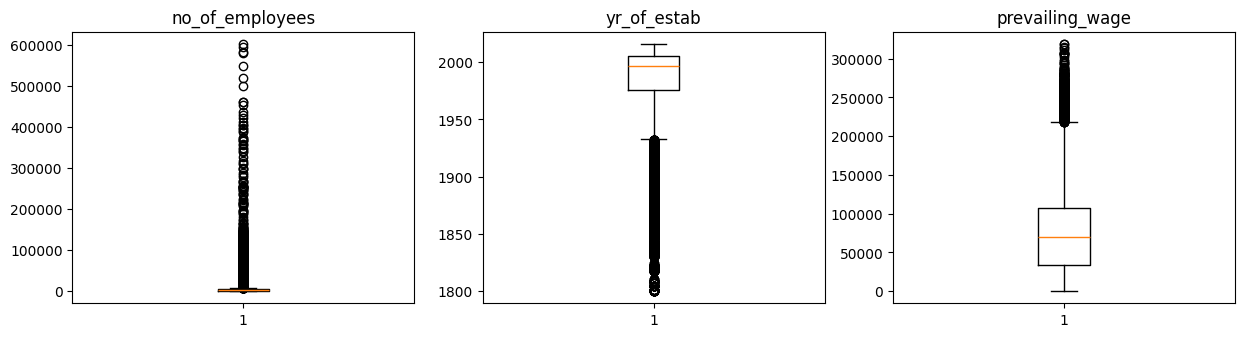

In [ ]:
# Create separate boxplots for data[num_cols] to detect outliers:
plt.figure(figsize=(15, 12))

for i, variable in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    plt.boxplot(data[variable])
    plt.title(variable)

plt.show()


We observe outliers in all three numerical columns.

In [ ]:
# Treat the outliers in the no_of_employees column:
Q1 = data['no_of_employees'].quantile(0.25)
Q3 = data['no_of_employees'].quantile(0.75)

IQR = Q3-Q1 #calculate interquartile range

upper_whisker = Q3 + 1.5*IQR

upper_whisker

np.float64(7227.0)

In [ ]:
# Assigning the outliers the value of the upper_whisker:
data.loc[data['no_of_employees'] > upper_whisker, 'no_of_employees'] = upper_whisker

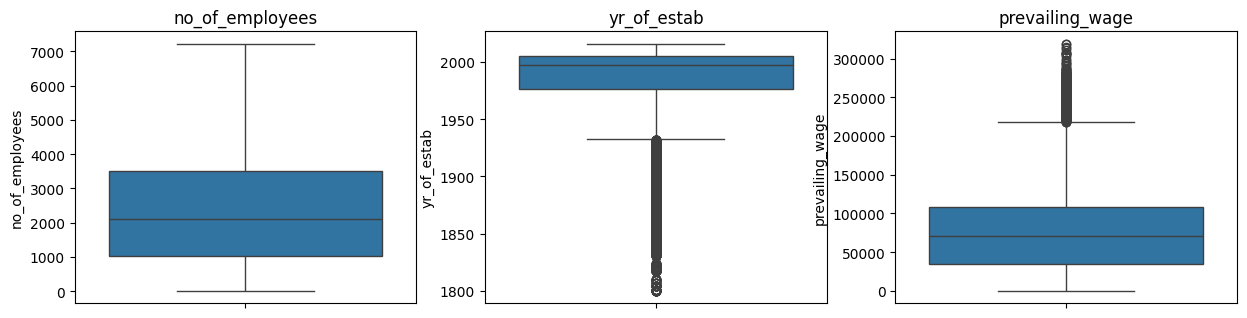

In [ ]:
# Outlier detection in numerical columns using boxplot after winsorizing outliers:
plt.figure(figsize=(15,12))

for i, variable in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(data[variable])
    plt.title(variable)

plt.show()

### Data Preparation for modeling

- We want to predict which visa will be certified.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [ ]:
# To prevent any confusion during the modeling process, determine which of the two target variable outputs is considered positive or 1:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

# Assign target variable y and predictor variables X:
y = data['case_status']
X = data.drop(['case_status'], axis=1)

# Encode categorical X variables. Create dummies:
X = pd.get_dummies(X, drop_first=True)

# Split data in train, test (but not validation) sets in 70:30 ratio:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)




Observation: When dealing with imbalanced datasets (where one class is significantly more frequent than the other), it helps to prevent the model from being biased towards the majority class.  

In this case, since y represents ['case_status'] (Certified or Denied), using stratify=y parameter in the train_test_split function ensures that the split preservers the proportion of the target variable y in both training and testing datasets.  

It means that the percentage of 'Certified' and 'Denied' cases will be approximately the same in X_train, y_train, X_test and y_test, as it is in the original X and y.

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of test set :  (7644, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64


## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,2495.034929,1874.429628,11.0000,1022.00,2109.00,3504.0000,7227.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
case_status,25480.0,0.667896,0.470977,0.0000,0.00,1.00,1.0000,1.00


## Model evaluation criterion

### Model can make wrong predictions as:

1. Model predicts that the visa application will get certified but in reality, the visa application should get denied.
2. Model predicts that the visa application will not get certified but in reality, the visa application should get certified.

### Which case is more important?
* Both the cases are important as:

* If a visa is certified when it had to be denied a wrong employee will get the job position, while a US citizen will miss out on the opportunity to work that position.

* If a visa is denied when it had to be certified, the U.S. will lose a suitable human resource that can contribute to the economy.



### How to reduce the losses?

* `F1 Score` can be used as the metric for evaluation of the model, the greater the F1  score, the higher are the chances of minimizing False Negatives and False Positives.
* We will use balanced class weights so that model focuses equally on both classes.

**First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.**
* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearn function will be used to plot the confusion matrix.

In [ ]:
# Define function to compute different metrics to check performance of a classification model built using sklearn:


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# Define function to creat confusion matrix, a table that summarizes the performance of a classification model:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Building bagging and boosting models

Bagging builds multiple independent models in parallel, while boosting builds models sequentially, with each new model correcting the errors of the previous one.

Bagging aims to reduce variance and improve robustness by averaging, while boosting focuses on reducing bias by iteratively improving accuracy on difficult data points.

In [ ]:
# Define bagging (bootstrap aggregating) classifier with random_state=1:
bagging_classifier = BaggingClassifier(random_state=1)

# Fit the bagging classifier on the training data:
bagging_classifier.fit(X_train, y_train)


BaggingClassifier(random_state=1)

#### Checking bagging_clf model performance on training set:

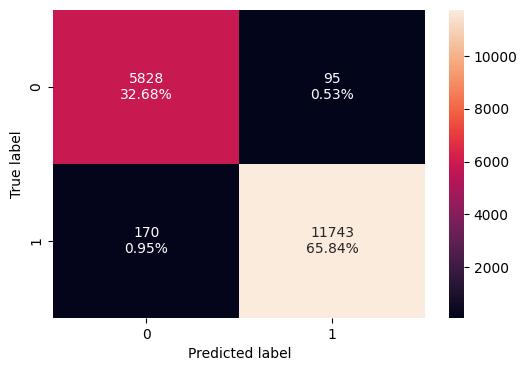

In [ ]:
# Create a confusion matrix for the training data:
confusion_matrix_sklearn(bagging_classifier, X_train, y_train)

In [ ]:
# Check the performance of the bagging model on the training data:
bagging_classifier_model_train_perf = model_performance_classification_sklearn(bagging_classifier, X_train, y_train)
bagging_classifier_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.985142,0.98573,0.991975,0.988843


#### Checking bagging_clf model performance on test set:

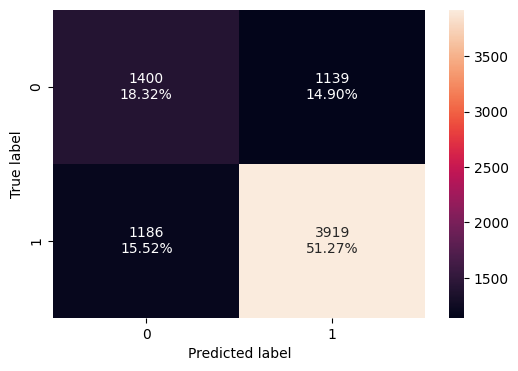

In [ ]:
confusion_matrix_sklearn(bagging_classifier, X_test, y_test)


In [ ]:
# Check the performance of the bagging model on the test set:
bagging_classifier_model_test_perf = model_performance_classification_sklearn(bagging_classifier, X_test, y_test)
bagging_classifier_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.69584,0.767679,0.774812,0.771229


We observe that the bagging model seem to have been overfitted on the training data.

### Hyperparameter Tuning - Bagging Classifier

**Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase.

- For Gradient Boosting:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```

In [ ]:
# Choose the type of classifier:
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from:
param_grid = {
  'max_samples': [0.8, 0.9, 1],
  'max_features': [0.7, 0.8, 0.9],
  'n_estimators': [30, 50, 70],
}

In [ ]:
# Type of scoring used to compare parameter combinations:
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search:
grid_obj = GridSearchCV(bagging_estimator_tuned, param_grid, cv=5, scoring=scorer)
grid_obj = grid_obj.fit(X_train, y_train)

In [ ]:
# Set the CLF (classifier) to the best combination of parameters:
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data:
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.8, n_estimators=70,
                  random_state=1)

#### Checking tuned bagging model performance on training set:

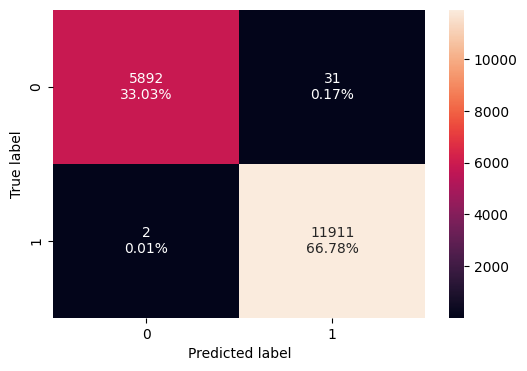

In [ ]:
# Create confusion matrix for training data on tuned estimator:
confusion_matrix_sklearn(bagging_estimator_tuned, X_train, y_train)



In [ ]:
# Check performance of tuned bagging estimator model on training set:
bagging_estimator_tuned_model_train_perf = model_performance_classification_sklearn(bagging_estimator_tuned, X_train, y_train)
bagging_estimator_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.99815,0.999832,0.997404,0.998617


#### Checking tuned bagging estimator model performance on test set:

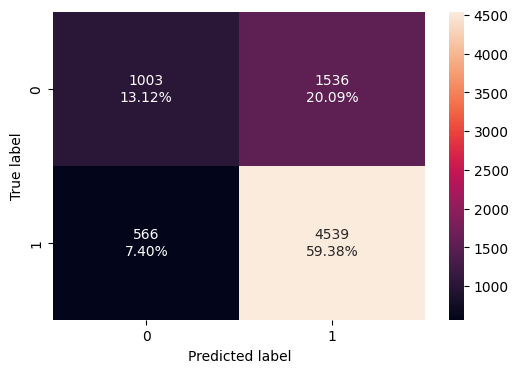

In [ ]:
# Create confusion matrix for test data on tuned estimator model:
confusion_matrix_sklearn(bagging_estimator_tuned, X_test, y_test)

In [ ]:
# Check performance of tuned bagging model on test set:
bagging_estimator_tuned_model_test_perf = model_performance_classification_sklearn(bagging_estimator_tuned, X_test, y_test)
bagging_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.725013,0.889128,0.74716,0.811986


We observe a slight improvement in the F1 score after tuning the bagging classifier model (0.79 pre-tuned, 0.81 tuned)

## Decision Tree - Model Building and Hyperparameter Tuning

### Decision Tree Model

In [ ]:
# Define the Decision Tree classifier with random state = 1:
decision_tree_clf = DecisionTreeClassifier(random_state=1)

# Fit the Decision Tree Classifier on the training data:
decision_tree_clf_fit = decision_tree_clf.fit(X_train, y_train)
decision_tree_clf_fit

DecisionTreeClassifier(random_state=1)

#### Checking model performance on training set

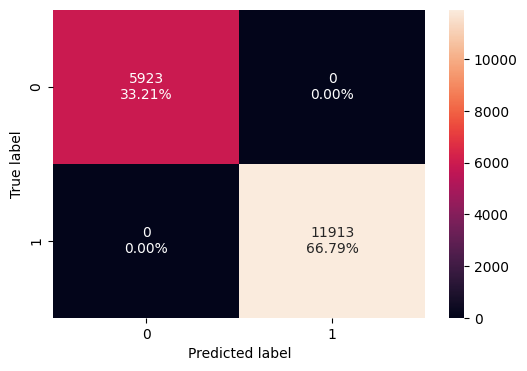

In [ ]:
# Create confusion matrix for training data:
confusion_matrix_sklearn(decision_tree_clf, X_train, y_train)

In [ ]:
# Check Decision Tree model performance on training set:
decision_tree_clf_model_train_perf = model_performance_classification_sklearn(decision_tree_clf_fit, X_train, y_train)
decision_tree_clf_model_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Checking model performance on test set:

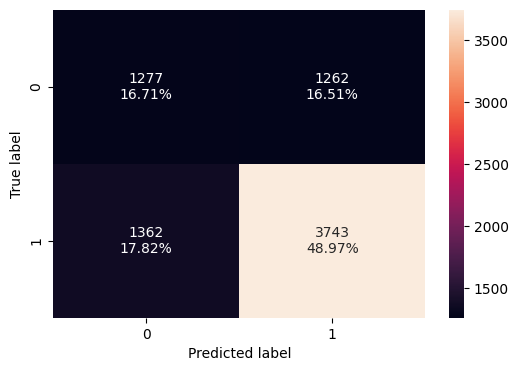

In [ ]:
# Create confusion matrix on test set:
confusion_matrix_sklearn(decision_tree_clf, X_test, y_test)

In [ ]:
# Check the performance of the decision tree model on the test data:
decision_tree_clf_model_test_perf = model_performance_classification_sklearn(decision_tree_clf_fit, X_test, y_test)
decision_tree_clf_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.656724,0.733203,0.747852,0.740455


### Hyperparameter Tuning - Decision Tree

In [ ]:
# Choose the type of classifier:
decision_tree_estimator_tuned = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from:
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

In [ ]:
# Type of scoring used to compare parameter combinations:
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid_search
grid_obj = GridSearchCV(decision_tree_estimator_tuned, param_grid, cv=5, scoring=scorer)
grid_obj = grid_obj.fit(X_train, y_train)

In [ ]:
# Set the CLF to the best combination of parameters:
decision_tree_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data:
decision_tree_estimator_tuned.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, random_state=1)

#### Check tuned Decision Tree model performance on training set:

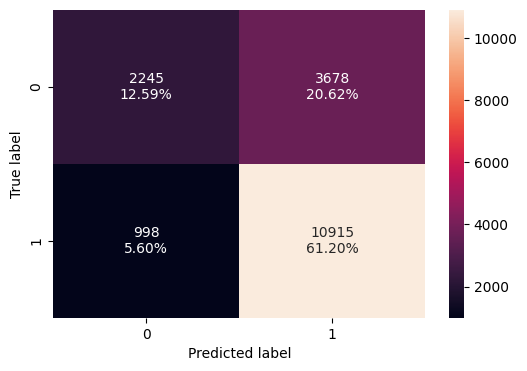

In [ ]:
# Create confusion matrix for trained data on the tuned decision tree estimator:
confusion_matrix_sklearn(decision_tree_estimator_tuned, X_train, y_train)

In [ ]:
# Check the performance of tuned decision tree estimator on trained data:
decision_tree_estimator_tuned_model_train_perf = model_performance_classification_sklearn(decision_tree_estimator_tuned, X_train, y_train)
decision_tree_estimator_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.737834,0.916226,0.747961,0.823587


#### Check tuned Decision Tree model performance on test set:

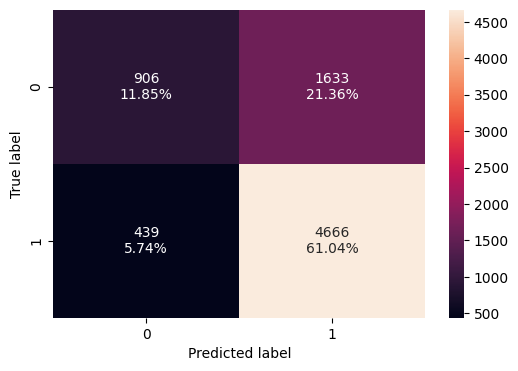

In [ ]:
# Create confusion matrix for test set on tuned decision tree model:
confusion_matrix_sklearn(decision_tree_estimator_tuned, X_test, y_test)

In [ ]:
# Check the performance of tuned decision tree model on test data:
decision_tree_estimator_tuned_model_test_perf = model_performance_classification_sklearn(decision_tree_estimator_tuned, X_test, y_test)
decision_tree_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.728938,0.914006,0.740753,0.818309


We observe the tuned decision tree model has an improved F1 score of 0.81 compared to 0.74 on a untuned model.

### Random Forest

In [ ]:
# Define the Random Forest classifier with random state = 1:
random_forest_clf = RandomForestClassifier(random_state=1)

# Fit the Random Forest classifier on the training data:
random_forest_clf_fit = random_forest_clf.fit(X_train,y_train)
random_forest_clf_fit

RandomForestClassifier(random_state=1)

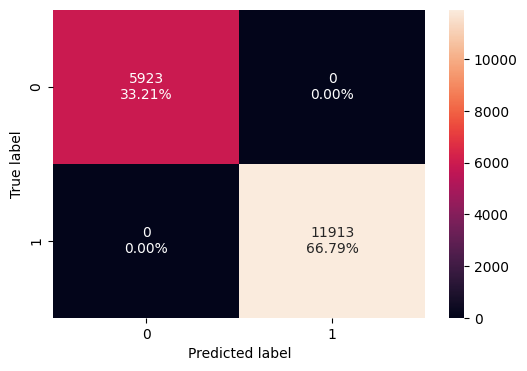

In [ ]:
# Check Random Forest model performance on training data:
confusion_matrix_sklearn(random_forest_clf, X_train, y_train)

In [ ]:
# Calculating the metrics:
random_forest_clf_model_train_perf = model_performance_classification_sklearn(random_forest_clf_fit, X_train, y_train)
random_forest_clf_model_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Check random forest estimator model performance on test set:

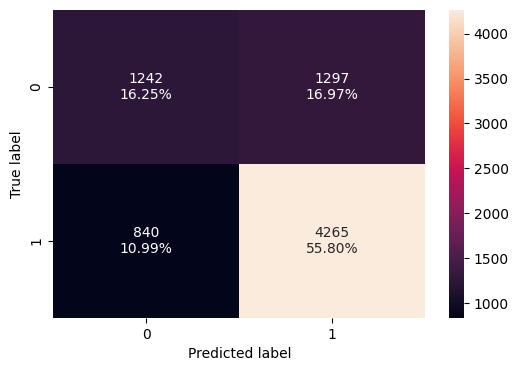

In [ ]:
# Check random forest estimator performance on test set:
confusion_matrix_sklearn(random_forest_clf, X_test, y_test)

In [ ]:
# Check random forest estimator model's metrics:
random_forest_clf_model_test_perf = model_performance_classification_sklearn(random_forest_clf_fit, X_test, y_test)
random_forest_clf_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.720434,0.835455,0.76681,0.799663


### Hyperparameter Tuning - Random Forest

In [ ]:
# Choose the classifier for a tuned Random Forest model:
random_forest_estimator_tuned = RandomForestClassifier(random_state=1)

param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

In [ ]:
# Type of scoring metric used to compare parameter combinations:
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search:
grid_obj = GridSearchCV(random_forest_estimator_tuned, param_grid, cv=5, scoring=scorer)
grid_obj = grid_obj.fit(X_train, y_train)

In [ ]:
# Set the CLF to the best combination of parameters:
random_forest_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data:
random_forest_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(max_samples=np.float64(0.4),
                       min_samples_leaf=np.int64(3), n_estimators=110,
                       random_state=1)

#### Check tuned Random Forest model performance on training set:

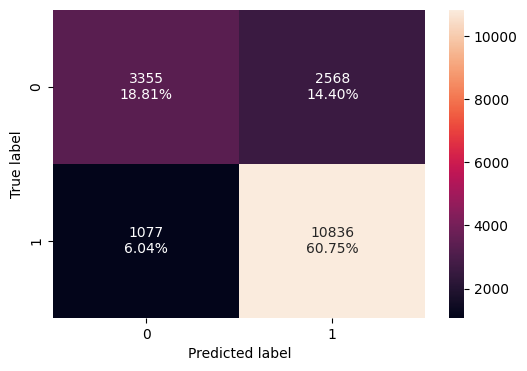

In [ ]:
# Create confusion matrix on tuned Random Forest model:
confusion_matrix_sklearn(random_forest_estimator_tuned, X_train, y_train)

In [ ]:
# Calculate the metrics of the tuned Random Forest model on training data:
random_forest_estimator_tuned_model_train_perf = model_performance_classification_sklearn(random_forest_estimator_tuned, X_train, y_train)
random_forest_estimator_tuned_model_train_perf


,Accuracy,Recall,Precision,F1
0,0.795638,0.909595,0.808415,0.856026


#### Check tuned random forest model performance on test set:

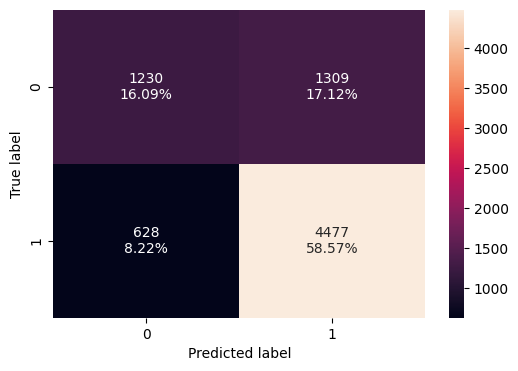

In [ ]:
# Check confusion matrix:
confusion_matrix_sklearn(random_forest_estimator_tuned, X_test, y_test)

In [ ]:
# Calculate the performance metrics of the tuned Random Forest model:
random_forest_estimator_tuned_model_test_perf = model_performance_classification_sklearn(random_forest_estimator_tuned, X_test, y_test)
random_forest_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.746599,0.876983,0.773764,0.822147


We observe that the F1 score of the test set is 0.82 while that of the training set is 0.84.  Not too bad of a discrepancy or score.

## Boosting - Model Building and Hyperparameter Tuning

In [ ]:
# Define the Boosting classifier with random state =1:
boosting_clf = AdaBoostClassifier(random_state=1)

# Fit the Boosting classifier on the training data:
boosting_clf_fit = boosting_clf.fit(X_train, y_train)
boosting_clf_fit

AdaBoostClassifier(random_state=1)

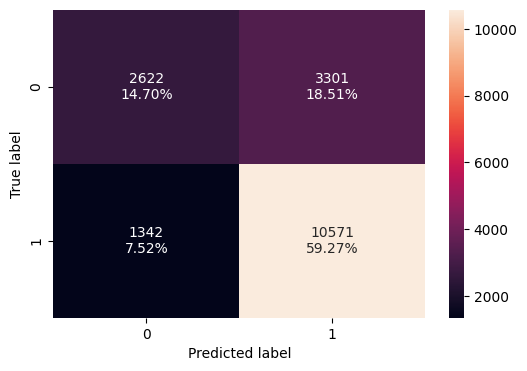

In [ ]:
# Check the Boosting model performance on the training data:
confusion_matrix_sklearn(boosting_clf, X_train, y_train)

In [ ]:
# Calculate the performance metrics of the boosting model on training data:
adaboosting_clf_model_train_perf = model_performance_classification_sklearn(boosting_clf_fit, X_train, y_train)
adaboosting_clf_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.739684,0.88735,0.762039,0.819934


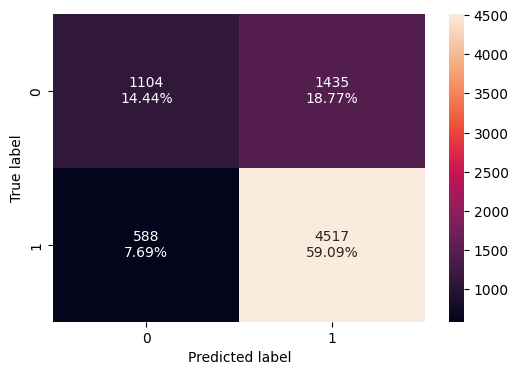

In [ ]:
# Check the confusion matrix of the boosting model on the test set:
confusion_matrix_sklearn(boosting_clf, X_test, y_test)

In [ ]:
# Calculate the performance metrics of the boosting model on the test set:
adaboosting_clf_model_test_perf = model_performance_classification_sklearn(boosting_clf_fit, X_test, y_test)
adaboosting_clf_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.735348,0.884819,0.758905,0.817039


### Hyperparameter Tuning - AdaBoost Classifier

In [ ]:
# Choose the type of classifier:
adaboost_estimator_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from:
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

In [ ]:
# Type of scoring used to compare parameter combinations:
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search:
grid_obj = GridSearchCV(adaboost_estimator_tuned, param_grid, cv=5, scoring=scorer)
grid_obj = grid_obj.fit(X_train, y_train)

In [ ]:
# Set the CLF to the best combination of parameters:
adaboost_estimator_tuned = grid_obj.best_estimator_

# Fit to the best algorithm to the data:
adaboost_estimator_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=np.int64(100),
                   random_state=1)

#### Checking tuned boosting model performance on training set:

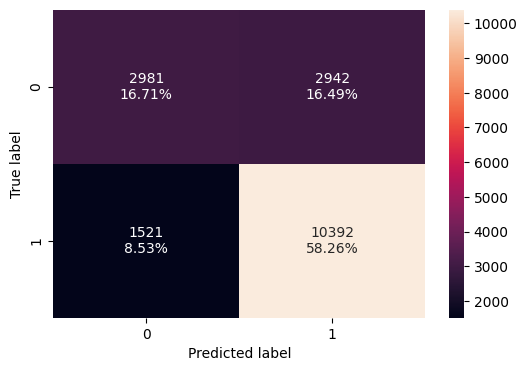

In [ ]:
# Check tuned boosting model performance on training set:
confusion_matrix_sklearn(adaboost_estimator_tuned, X_train, y_train)

In [ ]:
# Calculate the performance metrics of tuned model on training set:
adaboost_estimator_tuned_model_train_perf = model_performance_classification_sklearn(adaboost_estimator_tuned, X_train, y_train)
adaboost_estimator_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.749776,0.872324,0.779361,0.823227


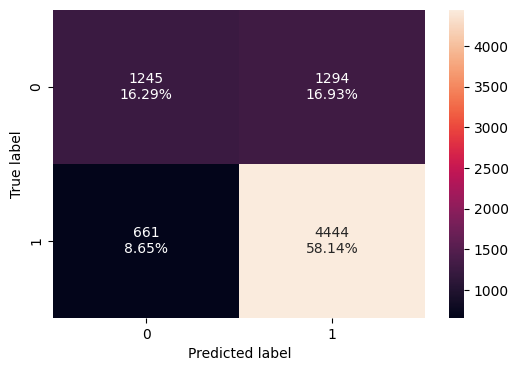

In [ ]:
# Check tuned boosting model performance on test set:
confusion_matrix_sklearn(adaboost_estimator_tuned, X_test, y_test)

In [ ]:
# Calculate the performance metrics of tuned boosting on test set:
adaboost_estimator_tuned_model_test_perf = model_performance_classification_sklearn(adaboost_estimator_tuned, X_test, y_test)
adaboost_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.744244,0.870519,0.774486,0.819699


For the adaboost classifier model, we observe f1 score of 0.81 in test compared to 0.82 in training

### Gradient Boosting Classifier

In [ ]:
# Define the Gradient Boost Classifier with random state = 1:
gradient_boosting_clf = GradientBoostingClassifier(random_state=1)

# Fit the Gradient Boost classifier on the training data:
gradient_boosting_clf_fit = gradient_boosting_clf.fit(X_train, y_train)
gradient_boosting_clf_fit

GradientBoostingClassifier(random_state=1)

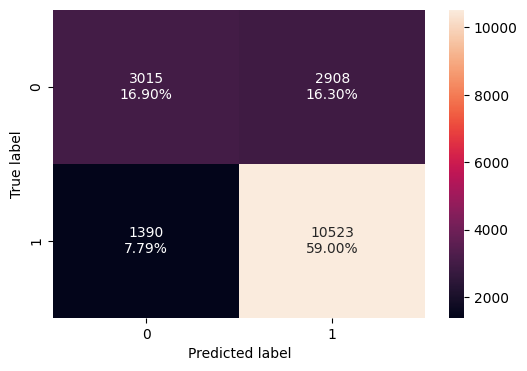

In [ ]:
# Create confusion matrix on training data:
confusion_matrix_sklearn(gradient_boosting_clf, X_train, y_train)

In [ ]:
# Calculate model performance metrics on the training data:
gradient_boosting_clf_model_train_perf = model_performance_classification_sklearn(gradient_boosting_clf_fit, X_train, y_train)
gradient_boosting_clf_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.759027,0.883321,0.783486,0.830414


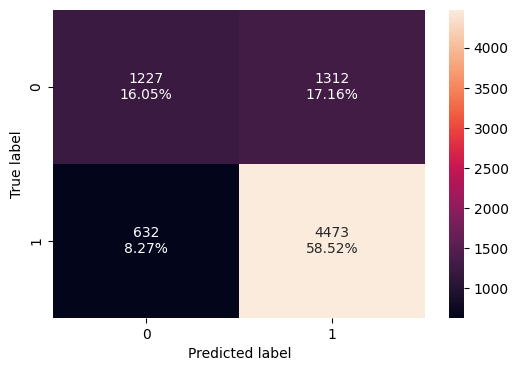

In [ ]:
# Create confusion matrix on test set:
confusion_matrix_sklearn(gradient_boosting_clf, X_test, y_test)


In [ ]:
# Calculate performance metrics of gradient boost model on test set:
gradient_boosting_clf_model_test_perf = model_performance_classification_sklearn(gradient_boosting_clf_fit, X_test, y_test)
gradient_boosting_clf_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.745683,0.8762,0.773207,0.821488


In [ ]:
#  Choose the type of classifier for a tuned Gradient Boost model:
gradient_boosting_estimator_tuned = GradientBoostingClassifier(random_state=1)

# Fit the tuned Gradient Boost model on the training data:
gradient_boosting_estimator_tuned_fit = gradient_boosting_estimator_tuned.fit(X_train, y_train)
gradient_boosting_estimator_tuned_fit


GradientBoostingClassifier(random_state=1)

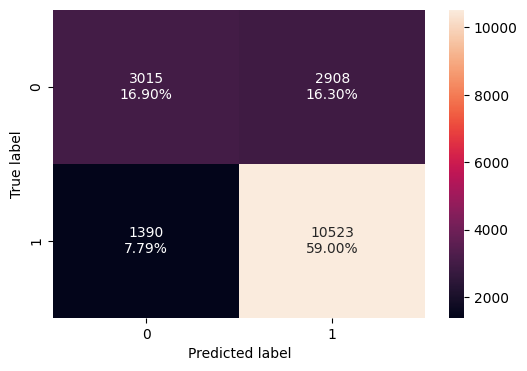

In [ ]:
# Create confusion matrix of tuned Gradient Boost model on training data:
confusion_matrix_sklearn(gradient_boosting_estimator_tuned, X_train, y_train)

In [ ]:
# Calculate performance metrics of tuned Gradient Boost model on training set:
gradient_boosting_estimator_tuned_model_train_perf = model_performance_classification_sklearn(gradient_boosting_estimator_tuned_fit, X_train, y_train)
gradient_boosting_estimator_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.759027,0.883321,0.783486,0.830414


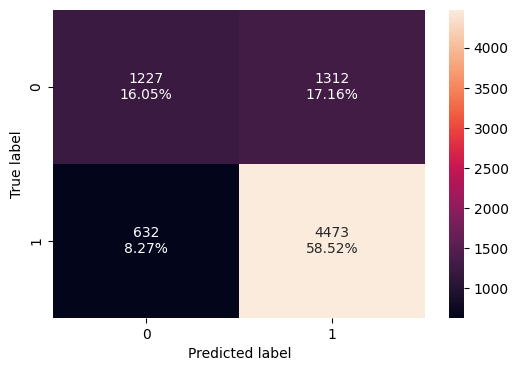

In [ ]:
# Create confusion matrix on test set:
confusion_matrix_sklearn(gradient_boosting_estimator_tuned_fit, X_test, y_test)

In [ ]:
# Calculate performance metrics on test set:
gradient_boosting_estimator_tuned_model_test_perf = model_performance_classification_sklearn(gradient_boosting_estimator_tuned_fit, X_test, y_test)
gradient_boosting_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.745683,0.8762,0.773207,0.821488


### XGBoost Classifier

In [ ]:
# Define the XGBoost Classifier with random state=1:
xgb_clf = XGBClassifier(random_state=1)

# Fit the XGB Classifier on the training data:
xgb_clf_fit = xgb_clf.fit(X_train, y_train)
xgb_clf_fit

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

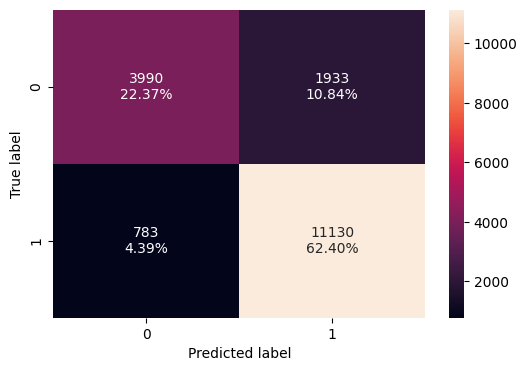

In [ ]:
# Check XGBoost model performance on training set:
confusion_matrix_sklearn(xgb_clf, X_train, y_train)

In [ ]:
# Calculate the performance metrics of the XGBoost model on training data:
xgb_clf_model_train_perf = model_performance_classification_sklearn(xgb_clf, X_train, y_train)
xgb_clf_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.847724,0.934273,0.852025,0.891256


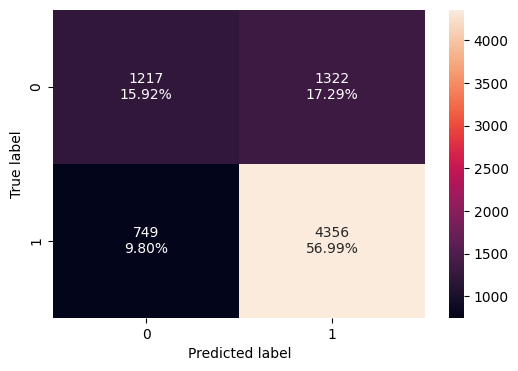

In [ ]:
# Check XGBoosting model performance on test set:
confusion_matrix_sklearn(xgb_clf, X_test, y_test)

In [ ]:
# Calculate metrics of XGBoost model performance on test set:
xgb_clf_model_test_perf = model_performance_classification_sklearn(xgb_clf, X_test, y_test)
xgb_clf_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.729069,0.853281,0.767172,0.807938


### Hyperparameter Tuning - XGBoost Classifier

In [ ]:
# Choose the type of classifier for XGBoost model:
xgb_estimator_tuned = XGBClassifier(random_state=1)

# Grid of parameters to choose from:
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}

In [ ]:
# Type of scoring used to compare parameter combinations:
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search:
grid_obj = GridSearchCV(xgb_estimator_tuned, param_grid, cv=5, scoring=scorer)
grid_obj = grid_obj.fit(X_train, y_train)

In [ ]:
# Set the CLF to the best combination of parameters:
xgb_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data:
xgb_estimator_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(50), n_jobs=None, num_parallel_tree=None, ...)

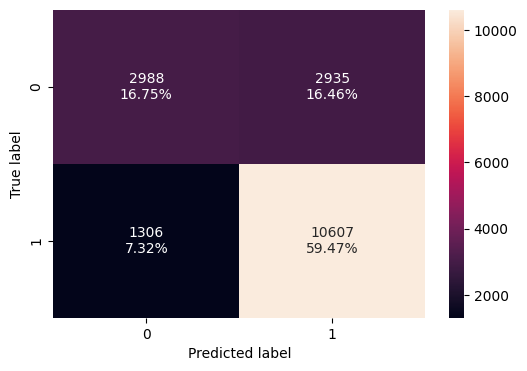

In [ ]:
# Create confusion matrix for training set on the tuned XGBoost model:
confusion_matrix_sklearn(xgb_estimator_tuned, X_train, y_train)

In [ ]:
# Calculate tuned XGBoost model performance for the training data:
xgb_estimator_tuned_model_train_perf = model_performance_classification_sklearn(xgb_estimator_tuned, X_train, y_train)
xgb_estimator_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.762222,0.890372,0.783267,0.833392


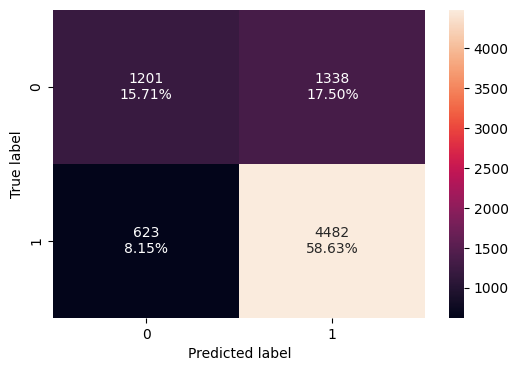

In [ ]:
# Create confusion matrix of tuned XGBoost model for test data:
confusion_matrix_sklearn(xgb_estimator_tuned, X_test, y_test)

In [ ]:
# Calculate performance metrics of tuned XGBoost model for test set:
xgb_estimator_tuned_model_test_perf = model_performance_classification_sklearn(xgb_estimator_tuned, X_test, y_test)
xgb_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.743459,0.877963,0.770103,0.820503


We observe that the f1 score of the tuned xg boost model is 0.82 on the test set , and 0.83 on the training set.

## Stacking Classifier

In [ ]:
# Define the Stacking Classifier:
# We need to provide a list of estimators to stack.
# Using some of the tuned models defined earlier as examples.
estimators = [
    ('rf', random_forest_estimator_tuned),
    ('xgb', xgb_estimator_tuned),
    ('ada', adaboost_estimator_tuned)
]

stacking_clf = StackingClassifier(estimators=estimators)

# Fit the Stacking Classifier on the training data:
stacking_clf_fit = stacking_clf.fit(X_train, y_train)
stacking_clf_fit

StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(max_samples=np.float64(0.4),
                                                       min_samples_leaf=np.int64(3),
                                                       n_estimators=110,
                                                       random_state=1)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eva...
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=np.int64(50),
                                              n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('ada',
                                AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                                                    random_state=1),
                                                   learning_rate=0.1,
                                                   n_estimators=np.int64(100),
                                                   random_state=1))])

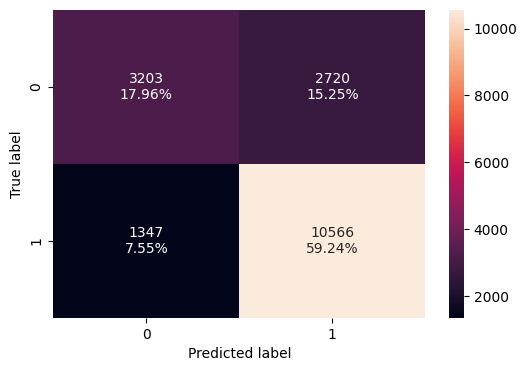

In [ ]:
# Create confusion matrix of the stacked classifier model for the training data:
confusion_matrix_sklearn(stacking_clf, X_train, y_train)


In [ ]:
# Calculate the performance metrics of the training data:
stacking_clf_model_train_perf = model_performance_classification_sklearn(stacking_clf_fit, X_train, y_train)
stacking_clf_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.771978,0.88693,0.795273,0.838605


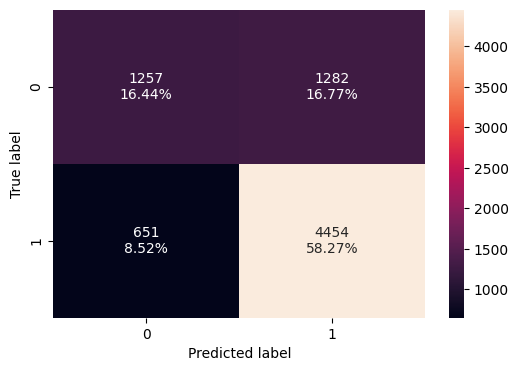

In [ ]:
# Create the confusion matrix of the test set:
confusion_matrix_sklearn(stacking_clf, X_test, y_test)


In [ ]:
# Calculate the performance metrics on the test set:
stacking_clf_model_test_perf = model_performance_classification_sklearn(stacking_clf_fit, X_test, y_test)
stacking_clf_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.747122,0.872478,0.776499,0.821695


## Model Performance Comparison and Final Model Selection

In [ ]:
# Let's compare the metrics of the various model performances on the training data:

models_train_comp_df = pd.concat(
    [
        decision_tree_clf_model_train_perf.T,
        decision_tree_estimator_tuned_model_train_perf.T,
        bagging_classifier_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        random_forest_clf_model_train_perf.T,
        random_forest_estimator_tuned_model_train_perf.T,
        adaboosting_clf_model_train_perf.T,
        adaboost_estimator_tuned_model_train_perf.T,
        gradient_boosting_clf_model_train_perf.T,
        gradient_boosting_estimator_tuned_model_train_perf.T,
        xgb_clf_model_train_perf.T,
        xgb_estimator_tuned_model_train_perf.T,
        stacking_clf_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
      'decision tree',
      'decision tree tuned',
      'bagging model',
      'bagging model tuned',
      'random forest',
      'random forest tuned',
      'adaboosting',
      'adaboosting tuned',
      'gradient boosting',
      'gradient boosting tuned',
      'xg boosting',
      'xg boosting tuned',
      'stacking',
  ]
print("training model performance comparison:")
models_train_comp_df

training model performance comparison:


,decision tree,decision tree tuned,bagging model,bagging model tuned,random forest,random forest tuned,adaboosting,adaboosting tuned,gradient boosting,gradient boosting tuned,xg boosting,xg boosting tuned,stacking
Accuracy,1.0,0.737834,0.985142,0.998150,1.0,0.795638,0.739684,0.749776,0.759027,0.759027,0.847724,0.762222,0.771978
Recall,1.0,0.916226,0.985730,0.999832,1.0,0.909595,0.887350,0.872324,0.883321,0.883321,0.934273,0.890372,0.886930
Precision,1.0,0.747961,0.991975,0.997404,1.0,0.808415,0.762039,0.779361,0.783486,0.783486,0.852025,0.783267,0.795273
F1,1.0,0.823587,0.988843,0.998617,1.0,0.856026,0.819934,0.823227,0.830414,0.830414,0.891256,0.833392,0.838605


In [ ]:
# testing performance comparison:
models_test_comp_df = pd.concat(
    [
        decision_tree_clf_model_test_perf.T,
        decision_tree_estimator_tuned_model_test_perf.T,
        bagging_classifier_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        random_forest_clf_model_test_perf.T,
        random_forest_estimator_tuned_model_test_perf.T,
        adaboosting_clf_model_test_perf.T,
        adaboost_estimator_tuned_model_test_perf.T,
        gradient_boosting_clf_model_test_perf.T,
        gradient_boosting_estimator_tuned_model_test_perf.T,
        xgb_clf_model_test_perf.T,
        xgb_estimator_tuned_model_test_perf.T,
        stacking_clf_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
      'decision tree',
      'decision tree tuned',
      'bagging model',
      'bagging model tuned',
      'random forest',
      'random forest tuned',
      'adaboosting',
      'adaboosting tuned',
      'gradient boosting',
      'gradient boosting tuned',
      'xg boosting',
      'xg boosting tuned',
      'stacking',
  ]
print("testing model performance comparison:")
models_test_comp_df

testing model performance comparison:


,decision tree,decision tree tuned,bagging model,bagging model tuned,random forest,random forest tuned,adaboosting,adaboosting tuned,gradient boosting,gradient boosting tuned,xg boosting,xg boosting tuned,stacking
Accuracy,0.656724,0.728938,0.695840,0.725013,0.720434,0.746599,0.735348,0.744244,0.745683,0.745683,0.729069,0.743459,0.747122
Recall,0.733203,0.914006,0.767679,0.889128,0.835455,0.876983,0.884819,0.870519,0.876200,0.876200,0.853281,0.877963,0.872478
Precision,0.747852,0.740753,0.774812,0.747160,0.766810,0.773764,0.758905,0.774486,0.773207,0.773207,0.767172,0.770103,0.776499
F1,0.740455,0.818309,0.771229,0.811986,0.799663,0.822147,0.817039,0.819699,0.821488,0.821488,0.807938,0.820503,0.821695


- We observe that hyper tuning the parameters for the gradient boosting model has no effect.  The performance metrics are identical for both untuned and tuned model.  

- The overall best performing model in the f1 score is the tuned random forest model, followed by the stacking and gradient boosting model, all at 0.82.

### Important features of the final model:

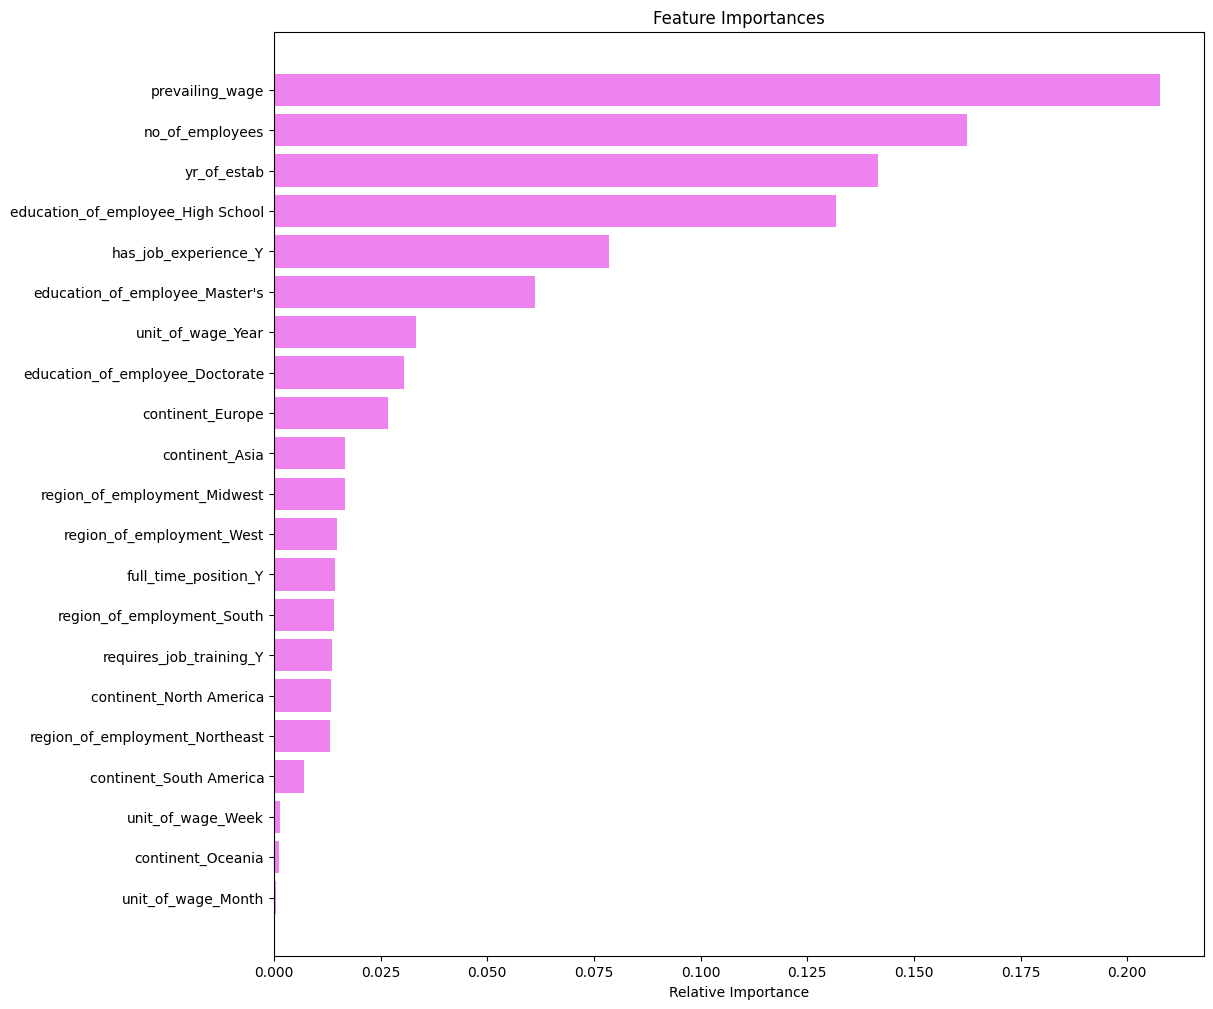

In [ ]:
feature_names = X_train.columns
importances = random_forest_estimator_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

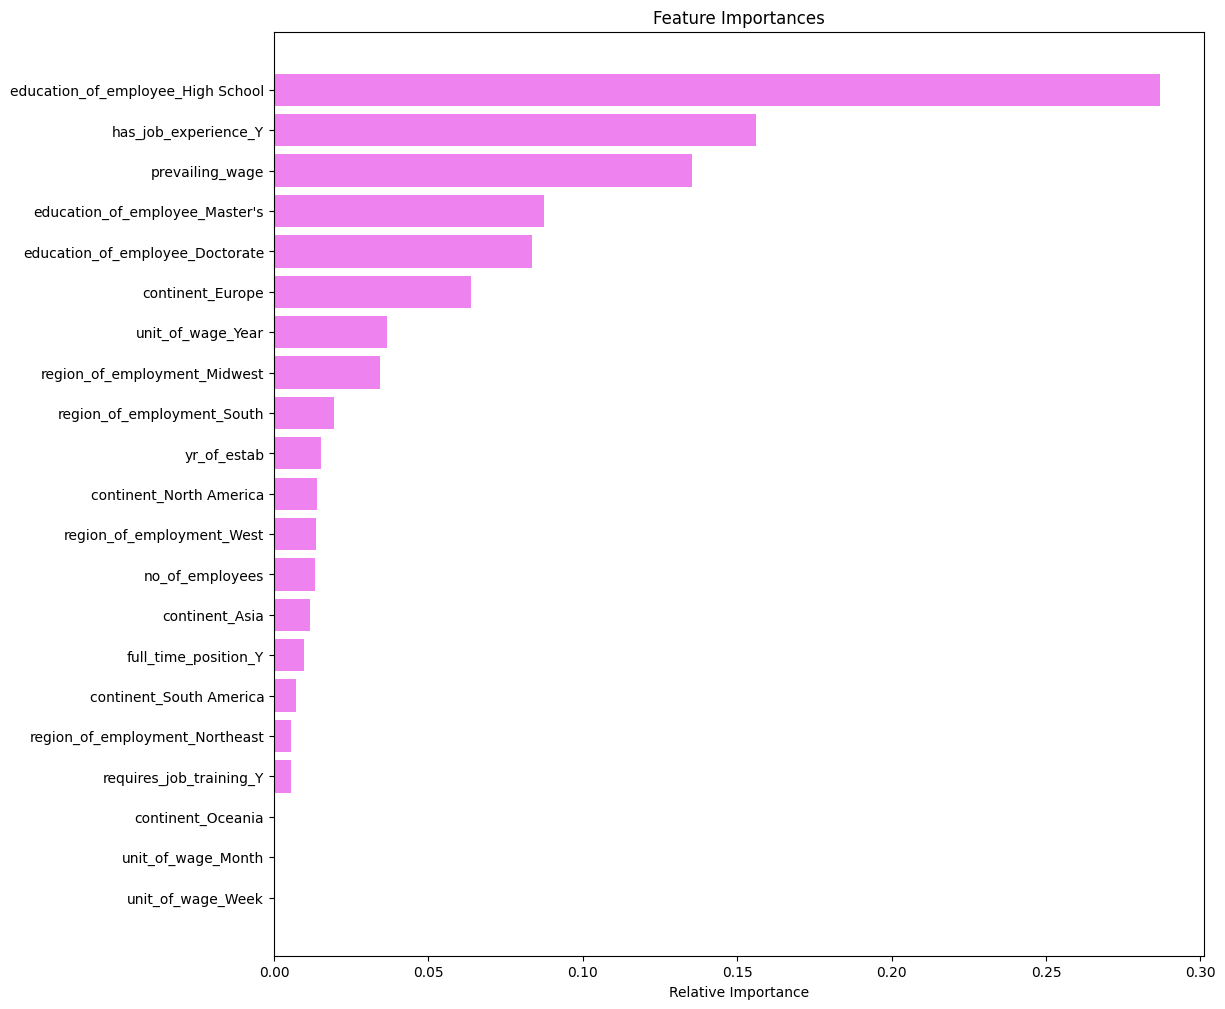

In [ ]:
feature_names = X_train.columns
importances = gradient_boosting_estimator_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

We observe that the features of importance in the best performing models diverge. Random Forests and Gradient Boosting use different strategies to combine the predictions of individual trees.

- Random Forests build many independent trees in parallel and average their predictions. Feature importance in Random Forests is often calculated based on how much each feature reduces impurity (like Gini impurity or entropy) averaged across all trees. Features that are useful early in many trees tend to get high importance.

- Gradient Boosting builds trees sequentially, where each new tree tries to correct the errors of the previous ones. Feature importance in Gradient Boosting is often calculated based on how much each feature contributes to the reduction of the loss function at each step. Features that are good at correcting specific types of errors in later stages might get higher importance. These different approaches can lead to different features being prioritized by the algorithms, even if they arrive at similar overall predictive accuracy.

While the F1 score measures the overall predictive power, feature importance reflects how each model internally leverages the features to make predictions. Different models can achieve similar results through different "strategies," leading to variations in which features appear most important to that specific model. It's a good reminder that overall performance metrics and feature importance plots provide different perspectives on the model.

**Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```

##  Will tuning the hyperparameters improve the model performance?

We observe that hyperparameters improve the performance in all, but the Gradient Boosting model.

While hyperparameter tuning aims to find better model configurations, it's not guaranteed to always yield a significant improvement if the starting point (default parameters) is already quite good for the given task or if the explored parameter space is limited.

In this specific case, since the metrics are identical, it strongly suggests that the grid search did not find a combination of parameters that improved the model's F1 score on the cross-validation folds beyond what the default settings achieved.


## Model Performance Comparison and Conclusions

The top scoring models all have an F1 score of 0.82:  The Tuned Random Forest, the Gradient Boosting, and the Stacked model.

- F1 score of 0.82 signifies a strong but not perfect model performance, as it represents a good balance between precision and recall.

- Since the F1 score ranges from 0 (worst) to 1 (perfect), a 0.82 indicates that the model is effective at correctly identifying positive cases while minimizing both false positives and false negatives.

- This score suggests the model has ample room for improvement but is already performing well enough to be a viable tool for many applications.

## Actionable Insights and Recommendations

Prevailing wage, education level, and job experience are directly related to the applicant's profile and job offer, and make these factors highly relevant for recommendations.   